# Project: ARENA(Australian Renewable Energy Agency) solar adoption in Melbourne

## Purpose
Solar energy has become one of the fastest-growing renewable energy sources in Australia. Many households and businesses are installing solar panel systems to reduce electricity costs and lower carbon emissions. This project analyses solar installation and solar capacity trends across Australian states and territories between 2011 and 2025.

This guide establishes standards for data analysis and reporting conducted by ARENA analysts. Its purpose is to ensure clarity, accuracy, consistency, and reproducibility across all internal and external publications, including reports, dashboards, presentations, and Jupyter Notebooks focused on Australia's renewable energy landscape. Adherence enhances the credibility and impact of ARENA's work.

Focusing on Melbourne's residental market, there will be different distinct solar adoption patterns, which may require different policies and incentives. 

**Objectives**:

* Examine trends in solar installations over time,
* Compare solar adoption between states and territories,
* Identify growth patterns in renewable energy usage across Australia.
* 
**Data Sources and References**
This analysis uses sensitive internal datasets provided by Australian Renewable Energy Agency (ARENA).ARENA is interested in understanding  the factors influencing solar energy adopt on across different states and territories in Australia. All data and copyright being used belong to ARENA.

All data remains the property of ARENA and is restricted to analytical and reporting purposes within the organisation. 
The data set includes postcode-level solar installation records, state/territory identifiers, and population estimates. This datasets are also provided by the Australian Bureau of Statistics (ABS).

**Links**

#### Postcode data

The Australian Postcode Data has been obtained from [here](https://github.com/matthewproctor/australianpostcodes).

#### Solar data

The data sets for solar adoption were last downloaded from the [Clean Energy Regulator website on 2024-06-05](https://cer.gov.au/markets/reports-and-data/small-scale-installation-postcode-data).

#### Housing data

The data sets were downloaded from [Kaggle](https://www.kaggle.com/datasets/anthonypino/melbourne-housing-market/data). It includes the following key (reproduced from the website):


* Both sgu-solar-capacity-2011-to-present-and-total and sgu-solar-installations-2011-to-present-and-total, Provided in starter pack for this assignment by NMTAFE.



### Methodology

Python was used to perform the data preparation, analysis, clustering, significance testing, and visualisation. The following libraries were used throughout the project:

* Pandas for data cleaning, transformation, aggregation, and merging.
* NumPy for numerical operations and data manipulation.
* Scikit-learn for data standardisation, clustering, and dimensionality reduction.
* SciPy for statistical significance testing.
* Matplotlib and Seaborn for data visualisation.

The analysis was conducted using the following process:

1. The Melbourne housing dataset, solar installation dataset, and solar capacity dataset were imported into Jupyter Notebook using Pandas.

2. Data quality checks were performed to identify missing values, duplicate records, and data type inconsistencies. Relevant variables were selected and prepared for analysis.

3. Housing sales records were aggregated by postcode to create postcode-level features including median property price, average room count, and average distance from Melbourne's CBD.

4. Solar installation and solar capacity data were aggregated by postcode and merged with the housing dataset to create a single dataset for analysis.

5. Feature extraction was performed to generate postcode-level indicators representing housing characteristics and solar adoption patterns.

6. The selected variables were standardised using StandardScaler to ensure that differences in measurement scales did not disproportionately influence the clustering results.

7. K-Means clustering was applied to segment Melbourne postcodes into groups with similar housing and solar adoption characteristics. The Elbow Method and Silhouette Score were used to determine an appropriate number of clusters and evaluate clustering effectiveness.

8. Cluster characteristics were analysed through summary statistics and visualised using pairplots, PCA visualisations, scatter plots, and geographic cluster mapping.

9. A Kruskal-Wallis significance test was conducted to determine whether solar installation levels differed significantly between the identified postcode clusters.

10. The results were interpreted to identify distinct solar adoption patterns and provide insights that may assist ARENA in developing targeted solar energy policies and incentive programs for the Melbourne residential market.


In [1]:
# install packages for said project 
%pip install pandas
%pip install numpy
%pip install seaborn
%pip install mathplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement mathplotlib (from versions: none)
ERROR: No matching distribution found for mathplotlib


In [1]:
# Open the csv 
import pandas as pd 

housing_df = pd.read_csv("Melbourne_housing_FULL.csv")

print(housing_df.shape)
housing_df.head() 

(34857, 21)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,2.5,3067.0,...,1.0,1.0,126.0,NaN,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra City Council,-37.7996,144.9984,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.8079,144.9934,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,2.5,3067.0,...,2.0,1.0,0.0,NaN,NaN,Yarra City Council,-37.8114,145.0116,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.8093,144.9944,Northern Metropolitan,4019.0


In [2]:
# Check Structure 
housing_df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 34857 entries, 0 to 34856
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         34857 non-null  str    
 1   Address        34857 non-null  str    
 2   Rooms          34857 non-null  int64  
 3   Type           34857 non-null  str    
 4   Price          27247 non-null  float64
 5   Method         34857 non-null  str    
 6   SellerG        34857 non-null  str    
 7   Date           34857 non-null  str    
 8   Distance       34856 non-null  float64
 9   Postcode       34856 non-null  float64
 10  Bedroom2       26640 non-null  float64
 11  Bathroom       26631 non-null  float64
 12  Car            26129 non-null  float64
 13  Landsize       23047 non-null  float64
 14  BuildingArea   13742 non-null  float64
 15  YearBuilt      15551 non-null  float64
 16  CouncilArea    34854 non-null  str    
 17  Lattitude      26881 non-null  float64
 18  Longtitude     26

In [3]:
# Checking for missing values 
empty_values = housing_df.isnull().sum() 

null_table = pd.DataFrame({
    "Missing Values": empty_values,
    "Percent Missing": (empty_values / len(housing_df) * 100)
})

null_table.sort_values(
    by="Percent Missing",
    ascending=False
)


,Missing Values,Percent Missing
BuildingArea,21115,60.576068
YearBuilt,19306,55.386293
Landsize,11810,33.881286
Car,8728,25.039447
Bathroom,8226,23.599277
Bedroom2,8217,23.573457
Lattitude,7976,22.882061
Longtitude,7976,22.882061
Price,7610,21.832057
Regionname,3,0.008607


In [4]:
# Check for duplicates
housing_df.duplicated().sum() 

np.int64(1)

In [5]:
# Dropping duplicates - just 1 found
housing_df = housing_df.drop_duplicates()
housing_df.duplicated().sum() # 0 

np.int64(0)

## Identify Solar Adoption patterns across Melbourne 
1. Check for how many Postcode
2. Cleaning missing values  
3. Drop tables that are not being used

In [6]:
#housing_df["Postcode"].nunique() #211
#housing_df["Postcode"].value_counts().head(20) 
housing_df["Regionname"].value_counts() 

Regionname
Southern Metropolitan         11836
Northern Metropolitan          9557
Western Metropolitan           6799
Eastern Metropolitan           4376
South-Eastern Metropolitan     1739
Eastern Victoria                228
Northern Victoria               203
Western Victoria                115
Name: count, dtype: int64

In [7]:
print("Unique Postcodes:", housing_df["Postcode"].nunique())

housing_df.groupby("Postcode").size().sort_values(ascending=False).head(20)

Unique Postcodes: 211


Postcode
3073.0    844
3046.0    638
3020.0    617
3121.0    612
3165.0    583
3058.0    556
3040.0    535
3204.0    518
3163.0    508
3012.0    497
3032.0    497
3146.0    491
3072.0    485
3181.0    468
3101.0    467
3186.0    456
3056.0    444
3084.0    442
3141.0    435
3122.0    428
dtype: int64

Before cleaning we need to make sure to think about the solar adoption patterns, meaning that each row in the final dataset should probably be 'One postcode' not 'One property sale'. Next step would be to create a postcode summary from the housing data set. 

### Aggregate the Postcode record for Melbourne Housing Table

In [8]:
# We want One postcode per its avearage housing features 
housing_by_postcode = (
    housing_df.groupby("Postcode").agg({
        "Price": "median",
        "Rooms": "mean",
        "Bedroom2": "mean",
        "Bathroom": "mean",
        "Car": "mean",
        "Landsize": "median",
        "Distance": "mean",
        "Propertycount": "mean"
    })
    .reset_index() 
)
housing_by_postcode.head()                

,Postcode,Price,Rooms,Bedroom2,Bathroom,Car,Landsize,Distance,Propertycount
0,3000.0,637500.0,1.985294,1.769231,1.261538,0.793651,0.0,1.743137,17496.0
1,3002.0,897500.0,2.067797,2.146341,1.487805,1.075000,0.0,1.398305,3040.0
2,3003.0,1010000.0,2.530303,2.491228,1.543860,1.125000,71.5,2.445455,2230.0
3,3006.0,595000.0,2.052632,2.035714,1.392857,0.910714,0.0,1.009211,8400.0
4,3008.0,795000.0,2.375000,2.400000,1.800000,1.600000,0.0,1.712500,4707.0


In [9]:
# Inspect Aggregated data for NaN values 
housing_by_postcode.shape
housing_by_postcode.info()
housing_by_postcode.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 211 entries, 0 to 210
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Postcode       211 non-null    float64
 1   Price          209 non-null    float64
 2   Rooms          211 non-null    float64
 3   Bedroom2       210 non-null    float64
 4   Bathroom       210 non-null    float64
 5   Car            209 non-null    float64
 6   Landsize       206 non-null    float64
 7   Distance       211 non-null    float64
 8   Propertycount  211 non-null    float64
dtypes: float64(9)
memory usage: 15.0 KB


Postcode         0
Price            2
Rooms            0
Bedroom2         1
Bathroom         1
Car              2
Landsize         5
Distance         0
Propertycount    0
dtype: int64

In [10]:
# Fill in remaining missing values with the median of each column

housing_by_postcode_clean = housing_by_postcode.copy()

cols_to_fill = ["Price",
                "Bedroom2",
                "Bathroom",
                "Car",
                "Landsize" 
               ]
for col in cols_to_fill:
    housing_by_postcode_clean[col] = (
        housing_by_postcode_clean[col].fillna(housing_by_postcode_clean[col].median())
    )
housing_by_postcode_clean.isnull().sum()


Postcode         0
Price            0
Rooms            0
Bedroom2         0
Bathroom         0
Car              0
Landsize         0
Distance         0
Propertycount    0
dtype: int64

In [11]:
# save this file 
housing_by_postcode_clean.to_csv(
    "housing_by_postcode_clean.csv",
    index=False
)

Missing values remaining after postcode aggregation were minimal (less than 5 postcode record per
variable). To preserve postcode coverage for clustering analysis, missing values were placed using the median of each variable rather than removing records. 

## Solar Dataset Source 
The solar installation and solar capacity datasets used in this analysis were prepared as a part of a previous ARENA solar energy analysis project. The dataset contain postcode-level solar installation quantities and solar capacity (kW) across Australia from 2011 and 2025. 

As part of previous analysis, the datasets were cleaned and transformed by by: 
* Removing historical columns that were not required for the analysis.
* Converting the datasets from wide format to long format.
* Mapping postcodes to Australian states and territories.
* Removing invalid postcode records.
* Converting monthly records into a standardized date format for analysis.

To avoid duplicating preprocessing work, the cleaned datasets from the previous assignment were reused as the starting point for this Melbourned residential solar adoption analysis.

The two cleaned datasets used are: 
* **solar_capacity_long.csv** - postcode level solar capacity data measured in kilowatts (kW).
* **solar_installations_long.csv** - postcode level solar installation quantities.

These datasets will be further filtered and aggregated to support postcode level clustering and integration with Melbourne housing market data. 

In [12]:
# Open the csv 
import pandas as pd 

solar_capacity_df = pd.read_csv("solar_capacity_long.csv")

print(solar_capacity_df.shape)
solar_capacity_df.head() 

(486464, 6)


,Postcode,State/Territory,date,Solar_Capicity_kW,year,Year
0,800,NT,2011-01-01,0.00,2011.0,2011.0
1,801,NT,2011-01-01,0.00,2011.0,2011.0
2,803,NT,2011-01-01,0.00,2011.0,2011.0
3,804,NT,2011-01-01,0.00,2011.0,2011.0
4,810,NT,2011-01-01,3.02,2011.0,2011.0


In [13]:
# Open the csv 
import pandas as pd 

solar_installations_df = pd.read_csv("solar_installations_long.csv")

print(solar_installations_df.shape)
solar_installations_df.head() 

(486464, 6)


,Postcode,State/Territory,date,Solar_Installations,year,Year
0,800,NT,2011-01-01,0,2011.0,2011.0
1,801,NT,2011-01-01,0,2011.0,2011.0
2,803,NT,2011-01-01,0,2011.0,2011.0
3,804,NT,2011-01-01,0,2011.0,2011.0
4,810,NT,2011-01-01,2,2011.0,2011.0


Now we're getting the solar data  into the same format as the housing data. So before merging there are a few steps we need to follow:

1. **Check for Melbourne postcodes only**
2. **Filter solar data to Melbourne postcodes**
3. **Aggregate capacity by postcode**
4. **Aggregate installations by postcode**
5. **Merge the two solar datasets**
6. **Check for any missing values**
7. **Save the clean dataset to csv file** 

In [14]:
# # Step 1 - Create a postcode list 
melb_postcodes = housing_by_postcode_clean["Postcode"].unique()

print(melb_postcodes)

[3000. 3002. 3003. 3006. 3008. 3011. 3012. 3013. 3015. 3016. 3018. 3019.
 3020. 3021. 3022. 3023. 3024. 3025. 3027. 3028. 3029. 3030. 3031. 3032.
 3033. 3034. 3036. 3037. 3038. 3039. 3040. 3041. 3042. 3043. 3044. 3046.
 3047. 3048. 3049. 3051. 3052. 3053. 3054. 3055. 3056. 3057. 3058. 3059.
 3060. 3061. 3064. 3065. 3066. 3067. 3068. 3070. 3071. 3072. 3073. 3074.
 3075. 3076. 3078. 3079. 3081. 3082. 3083. 3084. 3085. 3087. 3088. 3089.
 3090. 3093. 3094. 3095. 3096. 3099. 3101. 3102. 3103. 3104. 3105. 3106.
 3107. 3108. 3109. 3111. 3113. 3115. 3116. 3121. 3122. 3123. 3124. 3125.
 3126. 3127. 3128. 3130. 3131. 3132. 3133. 3134. 3135. 3136. 3137. 3138.
 3139. 3140. 3141. 3142. 3143. 3144. 3145. 3146. 3147. 3148. 3149. 3150.
 3151. 3152. 3153. 3154. 3155. 3156. 3158. 3159. 3160. 3161. 3162. 3163.
 3165. 3166. 3167. 3168. 3169. 3170. 3171. 3172. 3173. 3174. 3175. 3177.
 3178. 3179. 3180. 3181. 3182. 3183. 3184. 3185. 3186. 3187. 3188. 3189.
 3190. 3191. 3192. 3193. 3194. 3195. 3196. 3197. 31

### Filter solar data to Melbourne postcodes 

In [15]:
# Step 2
# Filter solar data to Melbourne postcodes 
# Capacity: 

solar_capacity_melb = solar_capacity_df[
    solar_capacity_df["Postcode"].isin(melb_postcodes)
    ]

# Quantity: 
solar_installations_melb = solar_installations_df[
    solar_installations_df["Postcode"].isin(melb_postcodes)
    ]

print(solar_capacity_melb.shape)
print(solar_installations_melb.shape)

(37136, 6)
(37136, 6)


### Aggregate Capacity and Installations by postcodes 

In [16]:
# Step 3 
# Aggregate capacity by postcode

solar_capacity_postcode = (solar_capacity_melb.groupby("Postcode")["Solar_Capicity_kW"].sum().reset_index()
                          )

# rename column name 
solar_capacity_postcode.rename(
    columns={"Solar_Capicity_kW": "Total_Solar_Capacity_kW"},
    inplace=True
)

print(solar_capacity_postcode)

     Postcode  Total_Solar_Capacity_kW
0        3000                 6669.332
1        3002                 1976.254
2        3003                 4183.070
3        3006                 2795.530
4        3008                 3921.565
..        ...                      ...
206      3910                34299.437
207      3975                39001.283
208      3976                35245.117
209      3977               222795.984
210      3978               140757.760

[211 rows x 2 columns]


In [17]:
# Step 4
# Aggregate installations by postcode 

solar_installations_postcode = (
    solar_installations_melb.groupby("Postcode")["Solar_Installations"].sum().reset_index()
)

# rename column name 
solar_installations_postcode.rename(
    columns={"Solar_Installations": "Total_Solar_Installations"},
    inplace=True
) 
print(solar_installations_postcode)

     Postcode  Total_Solar_Installations
0        3000                        210
1        3002                        206
2        3003                        265
3        3006                         84
4        3008                        231
..        ...                        ...
206      3910                       5977
207      3975                       6766
208      3976                       7018
209      3977                      37420
210      3978                      19890

[211 rows x 2 columns]


### Merge two solar Datasets (Capacity + Quantity) 

In [18]:
# Step 5 - merge the two solar datasets 
solar_postcode = (solar_capacity_postcode.merge(solar_installations_postcode,
                                                on="Postcode",
                                                how="inner")
                 )
print(solar_postcode)

     Postcode  Total_Solar_Capacity_kW  Total_Solar_Installations
0        3000                 6669.332                        210
1        3002                 1976.254                        206
2        3003                 4183.070                        265
3        3006                 2795.530                         84
4        3008                 3921.565                        231
..        ...                      ...                        ...
206      3910                34299.437                       5977
207      3975                39001.283                       6766
208      3976                35245.117                       7018
209      3977               222795.984                      37420
210      3978               140757.760                      19890

[211 rows x 3 columns]


In [19]:
# Step 6 - check for missing values 
solar_postcode.isnull().sum()

Postcode                     0
Total_Solar_Capacity_kW      0
Total_Solar_Installations    0
dtype: int64

In [20]:
# Step 7: Save the clean solar dataset 
solar_postcode.to_csv(
    "solar_postcode.csv",
    index=False
)

## Merge two Datasets for Postcodes (housing and solar datasets for Melbourne)

In [21]:
# Before merging make sure both Postcode has the same data type 
housing_by_postcode_clean["Postcode"] = housing_by_postcode_clean["Postcode"].astype(int)
solar_postcode["Postcode"] = solar_postcode["Postcode"].astype(int)

# Merge both datasets with Postcode
merged_df = housing_by_postcode_clean.merge(
    solar_postcode,
    on="Postcode", 
    how="inner"
)

# Validation check
merged_df.shape
merged_df.head()
#merged_df.info()
#merged_df.isnull().sum()
#merged_df.describe()

,Postcode,Price,Rooms,Bedroom2,Bathroom,Car,Landsize,Distance,Propertycount,Total_Solar_Capacity_kW,Total_Solar_Installations
0,3000,637500.0,1.985294,1.769231,1.261538,0.793651,0.0,1.743137,17496.0,6669.332,210
1,3002,897500.0,2.067797,2.146341,1.487805,1.075000,0.0,1.398305,3040.0,1976.254,206
2,3003,1010000.0,2.530303,2.491228,1.543860,1.125000,71.5,2.445455,2230.0,4183.070,265
3,3006,595000.0,2.052632,2.035714,1.392857,0.910714,0.0,1.009211,8400.0,2795.530,84
4,3008,795000.0,2.375000,2.400000,1.800000,1.600000,0.0,1.712500,4707.0,3921.565,231


In [22]:
# Save to csv file 
merged_df.to_csv(
    "melbourne_housing_solar_merged.csv",
    index=False
)

## Data Standardization 
Now that we have our merged data set for our Melbourne housing and solar datasets we can now move on to Clustering. Before performing clustering analysis the merged housing and solar dataset must be standardized to ensure that all variables contribute equally to the clustering process. 

The dataset contains variables measured on different scales such as property prices, room counts, land sizes, property counts, solar installation quantities and now with solar installation quantities, and solar capacity measurements. Variables with larger numberical values can disproportionately influence distance calculations used by clustering algorithms such as K-Means. 

To address this issue, the selected clustering features will be standardized using the StandardScaler method. This process transforms each variable onto common scale which allows more meaningful comparison between the postcode characteristicsa ensuring that no single feature/variable dominates the clustering results. This standardized dataset will then be used for cluster identification and subsequent statistical analysis. 

In [23]:
# select clustering features - excluding Postcode since its and identifier for this particular dataset

features = merged_df[
    [
        "Price",
        "Distance", 
        "Rooms",
        "Total_Solar_Installations",
    ]
]

Feature selection was performed to reduce redundancy and focus on variables most relevant to solar adoption patterns. Property price, distance from the CBD, room count and total solar installations were selected as clustering variables. Land size was excluded due to the presence of extreme values and its potential to disproportionately influence cluster formation. The selected variables provide a balance between housing characteristics and solar adoption measures. 

In [24]:
# Standardize the data 
from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler() 
X_scaled = scaler.fit_transform(features)
X_scaled[:5]

array([[-0.79504455, -1.42262441, -2.65001551, -0.72876313],
       [-0.01469695, -1.4530896 , -2.46899665, -0.72943208],
       [ 0.32295345, -1.36057616, -1.45421052, -0.71956505],
       [-0.92260137, -1.48746528, -2.50227027, -0.74983507],
       [-0.32233398, -1.42533114, -1.79496116, -0.72525113]])

In [25]:
# convert to DataFrame 
import pandas as pd 
scaled_df = pd.DataFrame(
    X_scaled, 
    columns=features.columns
)

scaled_df.head() 

,Price,Distance,Rooms,Total_Solar_Installations
0,-0.795045,-1.422624,-2.650016,-0.728763
1,-0.014697,-1.453090,-2.468997,-0.729432
2,0.322953,-1.360576,-1.454211,-0.719565
3,-0.922601,-1.487465,-2.502270,-0.749835
4,-0.322334,-1.425331,-1.794961,-0.725251


In [26]:
scaled_df.describe()

,Price,Distance,Rooms,Total_Solar_Installations
count,2.110000e+02,2.110000e+02,2.110000e+02,2.110000e+02
mean,-8.418753e-17,1.683751e-16,-1.616401e-15,4.209376e-18
std,1.002378e+00,1.002378e+00,1.002378e+00,1.002378e+00
min,-1.473347e+00,-1.487465e+00,-2.650016e+00,-7.498351e-01
25%,-7.440218e-01,-7.871520e-01,-4.236476e-01,-5.030759e-01
50%,-2.773139e-01,-2.160694e-01,1.248778e-01,-2.686923e-01
75%,4.741458e-01,6.629921e-01,6.734033e-01,1.313402e-01
max,4.194678e+00,2.672907e+00,2.867505e+00,7.375240e+00


#### Data preparation and integration
> Prior to clustering, the selected housing and solar variables were standardized using the StandardScaler method from Scikit-learn.
> Standardized transformed each variable to have a mean of 0 and a standard deviation of 1.


## K-Means Clustering 
To identify distinct patterns of solar adoption across Melbourne postcodes, K-Means clustering will be applied to the standardized dataset. K-Means is an unsupervised machine learning algorithm that groups observations into clusters based on their similarity across selected variables. In this analysis, housing characteristics and solar adoption measures will be used to segment postcodes into groups with similar profiles. 

Before fitting the K-Means model, the optimal number of clusters will be determined using the Elbow Method. This technique evaluates the within-cluster sum of squares (WCSS) for different cluster values and helps identify a suitable number of clusters by locating the point where additional clusters provide diminishing improvements. 

In [27]:
# K-means clustering 
from sklearn.cluster import KMeans 

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

print(wcss)    

[844.0, 556.2603838230209, 433.71029996659104, 317.9079900003208, 255.43405153201667, 221.49478611214656, 193.9752061478457, 172.21433995580088, 154.08800043847836, 142.2269127650647]


#### Elbow Method

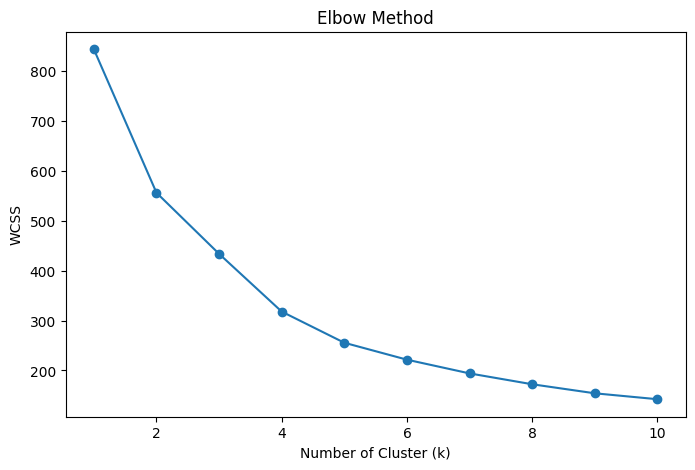

In [28]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Cluster (k)")
plt.ylabel("WCSS")
plt.show()

### Elbow Plot Analysis - Determining the Number of Clusters 
Looking at the elbow plot, there isn't a perfectly sharp elbow, but there is a noticeable bend around k=4. 

The Elbow method was used to determing an appropriate number of clusters of the K-Means analysis. The within-cluster sum of squares (WCSS) was calculated for cluster values ranging for 1 to 10 and plotted against the number of clusters. 

The graph showed a significant decrease in WCSS between one and four clusters. After four clusters, the decrease became smaller, indicating that adding more clusters provided limited improvement. Therefore, four clusters were selected for the final analysis.


In [29]:
# Fit K-means
# Assuming the elbow suggests cluster size = 4
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

merged_df["Cluster"] = clusters
merged_df["Cluster"].value_counts()

Cluster
0    92
3    65
1    50
2     4
Name: count, dtype: int64

In [30]:
cluster_summary = (
    merged_df
    .groupby("Cluster")
    [
        [
            "Price",
            "Distance",
            "Rooms",
            "Total_Solar_Installations",
            "Total_Solar_Capacity_kW"
        ]
    ]
    .mean()
    .round(2)
)
cluster_summary

,Price,Distance,Rooms,Total_Solar_Installations,Total_Solar_Capacity_kW
Cluster,,,,,
0,694351.09,27.74,3.44,5482.32,35255.56
1,1354766.00,12.22,3.35,3251.72,20688.26
2,564656.25,22.10,3.52,38983.50,253377.24
3,869669.23,7.91,2.70,2167.40,14443.51


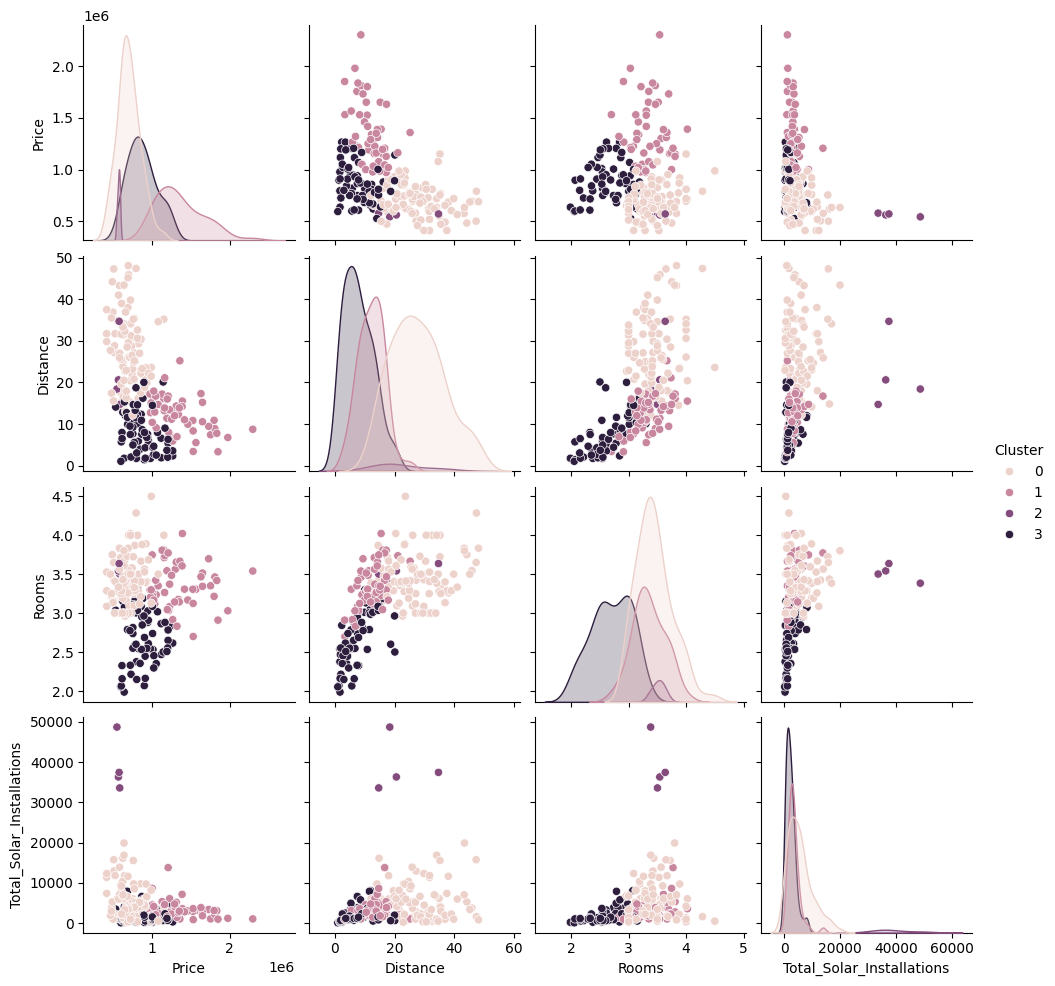

In [31]:
# Pairplot - used to visualise relationships between the selected clustering valriables and 
# assess the separation of postcode clusters. 
import seaborn as sns
import matplotlib.pyplot as plt

pairplot_features = [
    "Price",
    "Distance",
    "Rooms", 
    "Total_Solar_Installations",
    "Cluster"
]

sns.pairplot(
    merged_df[pairplot_features],
    hue="Cluster",
    # diag_kind="hist"
)

plt.show()

# Interpretation of clusters 

**Cluster 0**
This cluster has : 
* Low-to-mid property prices
* The greatest distance from the CBD
* Relatively large homes
* Moderate solar adoption

These postcodes appeart to represent outer suburban areas where detached housing is commone and solar adoption is higher than inner-city areas but lower than the highest-adoption cluster. 

**Cluster 1 - High Value Residential areas**
This cluster has:
* The highest property prices
* Located relatively close proximity to the CBD
* Moderate room counts
* Lower solar adoption

These postcodes appear to represent affluent suburbs where housing values are high but solar uptake is lower than in outer suburban areas. 

**Cluster 2 - High Solar Adoption Suburbs**
This cluster has the: 
* Lowest average property price
* Highest average room count
* Highest solar installation
* Highest solar capacity

This suggests these postcodes have adopted solar energy much more extensively than other groups. The larger number of rooms may indicate larger family homes with greater energy needs and roof space available for solar systems installations. 

**Cluster 3**
This cluster has:
* The shortest distance from the CBD
* The fewest rooms
* The lowest solar installations and capacity

This suggests these postcodes are likely inner-city locations with smaller housing, apartments or higher-density housing where solar installation opportunities may be more limited. 

**Overall Finding for ARENA**
The clustering analysis identified four distinct postcode groups with different housing and solar adoption characteristics. The results suggest that solar adoption is not evenly distributed across Melbourne. Postcodes with lower property prices and larger homes tend to exhibit higher levels of solar adoption. While inner-city and higher value suburbs show lower adoption rates. These findings indicate that different postcode groups may benefit from different solar incentive and policies approaches. 

### Silhouette score
Of all the cluster solutions tested, 4 clusters produced the best separation between postcode groups. 

In [32]:
from sklearn.metrics import silhouette_score 

score = silhouette_score(
    X_scaled,
    merged_df["Cluster"]
)

print("Silhouette Score:", score)


Silhouette Score: 0.3402723831475349


In [33]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    scores.append(score)

    print(f"k={k}: {score:.4f}")

k=2: 0.3193
k=3: 0.3373
k=4: 0.3403
k=5: 0.3062
k=6: 0.3187
k=7: 0.3100
k=8: 0.2987
k=9: 0.2995
k=10: 0.2817


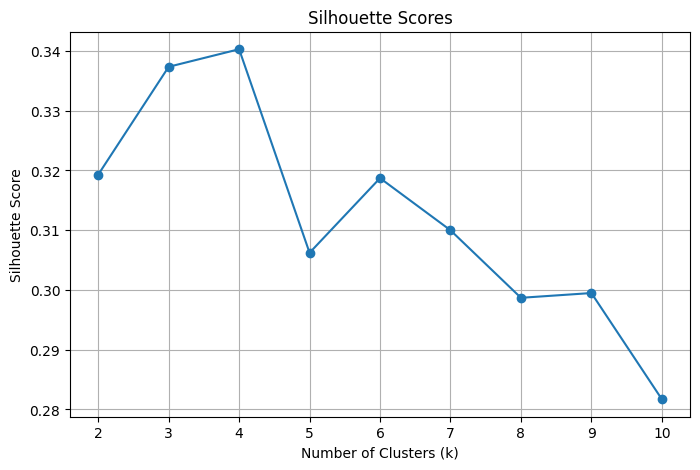

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    scores,
    marker="o"
)

plt.title("Silhouette Scores")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)

plt.show()

## Visual representation(s) - between Housing and Solar adoption in Melbourne

1. **Price vs Total Solar Installations**

>This scatter plot was used to examing the relationship between median property prices and solar adoption across Melbourne postcodes.

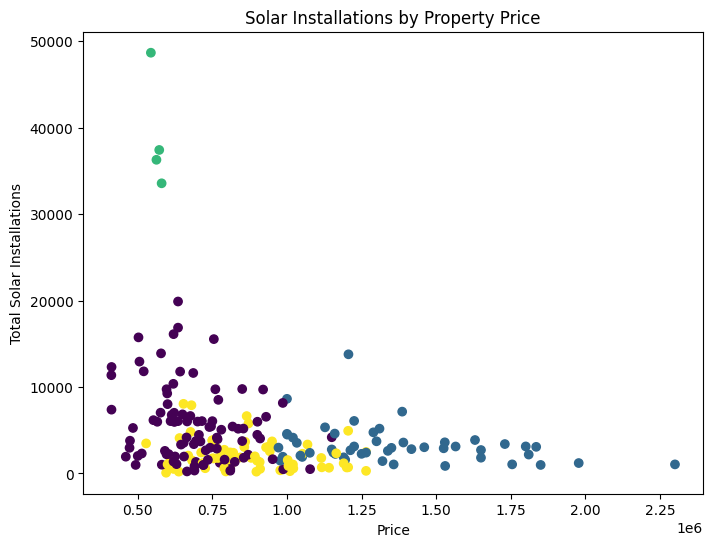

In [35]:
# Scatter plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    merged_df["Price"],
    merged_df["Total_Solar_Installations"],
    c=merged_df["Cluster"]
)

plt.xlabel("Price")
plt.ylabel("Total Solar Installations")
plt.title("Solar Installations by Property Price")
plt.show()

> The results show that solar installations are distributed across both lower and higher priced areas.

2. **Distance vs Total Solar Installations**

> The scatter plot was used to investigate the relationship between a postcode's distance from Melbourne's CBD and solar adoption levels. 

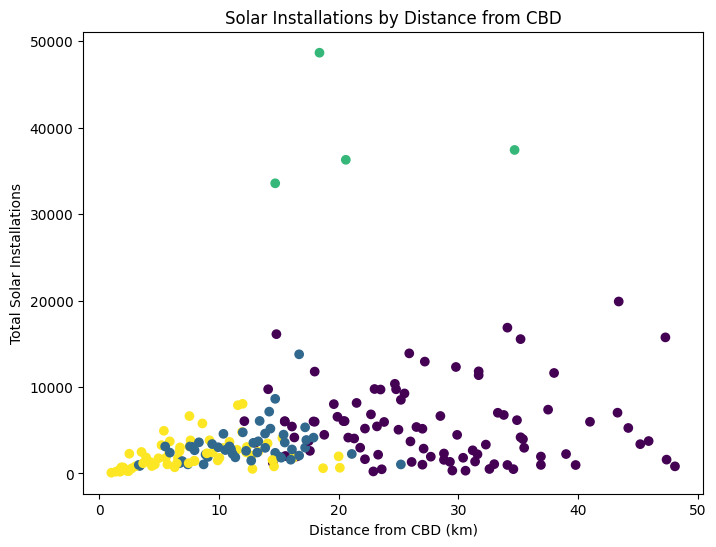

In [36]:
plt.figure(figsize=(8,6))

plt.scatter(
    merged_df["Distance"],
    merged_df["Total_Solar_Installations"],
    c=merged_df["Cluster"]
)

plt.xlabel("Distance from CBD (km)")
plt.ylabel("Total Solar Installations")
plt.title("Solar Installations by Distance from CBD")
plt.show()

> The results indicate that postcodes located further from the CBD generally experienced higher solar installation counts than inner city areas. This may be influenced by housing characteristics common in outer suburban areas such as increased roof space more suitable for solar systems. 

### PCA Scatter Plot 

>The PCA scatter plot was used to visualise the postcode clusters in two dimensions while retaining as much information from the original variables as possible. Each point represents a Melbourne postcode, and the colours indicated the cluster assigned by the K-Means algorithm. 

>The plot provides a visual assessment of cluster seperation and supports in indetifying solar adoption patterns across Melbourne. 

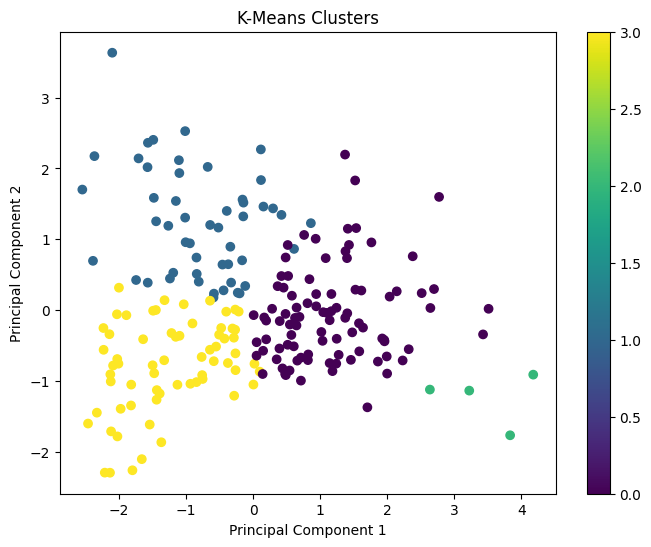

In [37]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=merged_df["Cluster"]
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters")

plt.colorbar(scatter)
plt.show()

**Centroid-based Clustering** methods such as K-Means, group data points based on their proximity to cluster centroids. 

## Other Clustering Techniques
**Density-based Clustering**
Density-based methods such as DBSCAN, form clusters grouping data points that are closing packed together and marks outliers as noise based on their density in the feature space. It identifies clusters as dense regions in the data space seperated by areas of lower density. Unlike K-Means which assumes clusters are compact and spherical, DBSCAN perform well in handling real-worl data that is Arbitrary shaped and identifies noise and outliers effectively.

> DBSCAN was also considered because it can identify outliers and does not require the number of clusters to be specified in advance. However, DBSCAN is sensitive to parameter selection and is generally more suitable for identifying irregularly shaped clusters and noise points.

> As the objective of this analysis was to segment Melbourne postcodes into distinct groups for evaluation, K-Means was considered the more appropriate technique.
>

Reference:

[Density-based-spatial Clustering](https://towardsdatascience.com/6-types-of-clustering-methods-an-overview-7522dba026ca/)

[Medium-DBSCAN Explained](https://medium.com/@abhaysingh71711/dbscan-explained-unleashing-the-power-of-density-based-clustering-72a51ba40fdf)

# Significance testing 
Significance testing is a statistical procedure used to determine whether the results of an experiment or study are likely due to chance or represent a real effect. It begins with forming two competing statements:  

**Hypothesis Testing** 
1) Null hypothesis (H₀) - "nothing is happening"

This assumes there is no effect or difference. 
Example: This teaching method does NOT improve marks


3) Alternative hypothesis (H₁) - "something is happening"

This suggests a genuine effect exists. 
Example: This teaching method improves marks



## Kruskal Wallis Test 
The **Kruskal-Wallis test (H test)** is a nonparametric statistical test used to comfpare three or more independent gorups to determine if there are statistically significant differences between them. 

Its key characteristics being: 
* Nonparametric: Does not assume a normal distribution, making it useful for skewed or ordinal data.
* Rank-based: Converts data to ranks instead of using raw values.
* Independent groups: Assumes that observations in different groups are independent of each other.

This test is to be used when comparing **three or more independent groups.** Or when sample sizes are **small or unequal across groups**. 

#### Hypotheses in the Kruskal-Wallis Test 
* Null Hypothesis (H₀): All groups have same central tendency or come from the same population. 
* Alternative Hypothesis (H₁): At least group has a different central tendency from the others.


**Reference URL's:**
- [Kruskal Wallis Test](https://www.geeksforgeeks.org/dsa/kruskal-wallis-test/)
- [Kruskal Wallis test in Python](https://tnathu-ai.medium.com/kruskal-wallis-test-in-python-2899a3c87a8b)


### Significance Testing for Solar Installations
A Kruskal-Wallis test was conducted to determine whether solar installation levels differed significantly between the postcode clusters identified by K-Means clustering model. 

This test was selected because the distribution of total solar installations remained positively skewed, with a small number of postcodes exhibiting higher installation counts than the majority of observations. While the data was standardized prior to clustering, standardization does not remove skewness or gurantee a normal distribution. As a result, a non parametic statistical test was considered more appropriate for this assignment. 

### Null and Alternative Hypotheses for Solar installations: 
**Property Price vs Solar Installation**

Null Hypothesis (H₀) 
> There is no statistical significant difference in solar installation levels between postcode clusters. 

Alternative Hypothesis(H₁)
> There is a statistically significant difference in solar installation levels between at least one of the postcode clusters.
 

In [38]:
# Because I have settled on 4 clusters 
from scipy.stats import kruskal 

cluster0 = merged_df[merged_df["Cluster"] == 0]["Total_Solar_Installations"]
cluster1 = merged_df[merged_df["Cluster"] == 1]["Total_Solar_Installations"]
cluster2 = merged_df[merged_df["Cluster"] == 2]["Total_Solar_Installations"]
cluster3 = merged_df[merged_df["Cluster"] == 3]["Total_Solar_Installations"]

h_stat, p_value = kruskal(
    cluster0,
    cluster1,
    cluster2,
    cluster3
)
print("H-statistic:", h_stat)
print("P-value:", p_value)



H-statistic: 45.88272173883781
P-value: 6.006643686756089e-10


### Results 
* H-statistic: 45.88272173883781
* P-value: 6.01 × 10⁻¹⁰
> or approximately:
> P-value = 0.0000000006 

**Determining the significance level**
* If the p-value is less than the significance level (α) = 0.05, at least one group differs significantly.
* If the p-value is greater than the significance level, we fail to reject the null hypothesis, meaning there is no strong evidence of differences among the groups.

**Decision**

Using significance level (α) = 0.05,
Since: 6.01 × 10⁻¹⁰ < 0.05 

**Interpretation**

This means that there is a statistically significant difference in solar installation levels between the postcode clusters. A Kruskal-Wallis test was conducted to determing whether solar installaton levels differed between the postcode slusters identified by the K-Means model. The test produced a p-value of less than 0.05, indicating that the differences observed between clusters were unlikely to have occured by chance. Therefore, the results suggest that Melbourne postcodes exhibit distince solar adoption patterns supporting the clustering analysis. 

> In conclusion, the significance test confirms that the ideantified postcode groups differ in solar adoption levels. This suggests that a single policy approach may not be suitable across all Melbourne postcodes, and targeted incentives may be more effective for increasing solar uptake.



In [48]:
# merged_df.columns

## Visualization of Results for Solar Installation within Melbourne

A geogrphic scatter plot was created usingpostcode latitude and longitude coordinates. The visualisation shows the spatial distribution of the clusters identified by the K-Means model and provides geographic context for solar adoption patterns across Melbourne. You can observe distinct postcodes across different areas. 

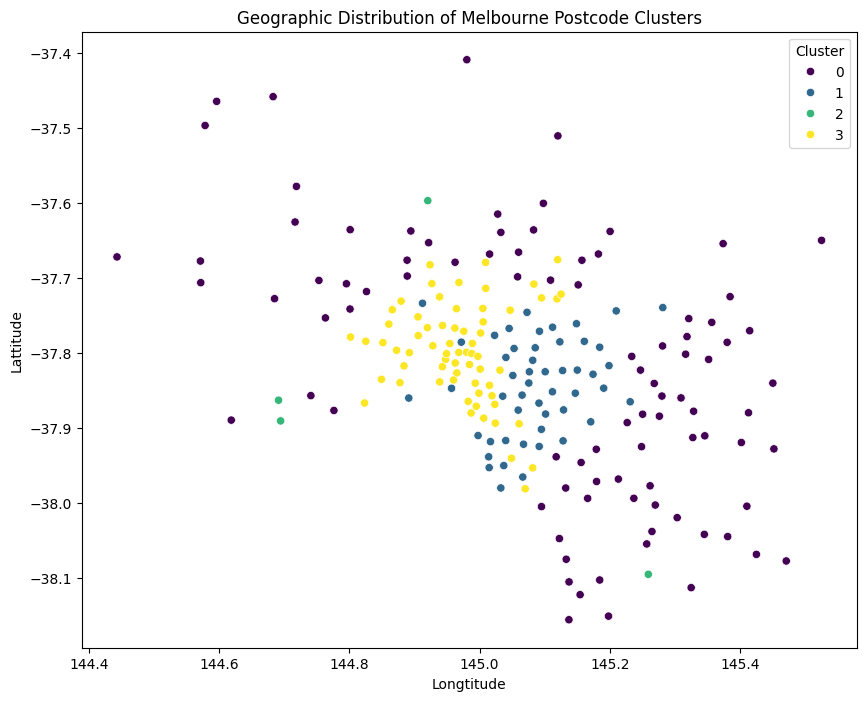

In [50]:
# Visualization of results - (geo spatial visulization recommended) 

geo_df = (
    housing_df.groupby("Postcode").agg({
        "Lattitude": "mean",
        "Longtitude": "mean"
    })
    .reset_index()
)
geo_df = geo_df.merge(
    merged_df[["Postcode", "Cluster"]],
    on="Postcode",
    how="inner"
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=geo_df,
    x="Longtitude",
    y="Lattitude",
    hue="Cluster",
    palette="viridis"
)

plt.title("Geographic Distribution of Melbourne Postcode Clusters")
plt.show()



### Report Conclusion 

This analysis combined Melbourne housing data with solar installation and capacity data with solar installation and capacity data to investigate solar adoption patterns. K-Means clustering identified four distinct postcode groups with different housing characteristics and levels of solar adoption. 
Cluster quality was assessed uging the Elbow Method and Silhouette score while a Kruskal-Wallis test helped confirm that solar installation levels differed isgnificantly between clusters. The findings suggest that solar adoption is not uniform acrsoss Melbourned and that clusters with higher average room counts generally exhibited higher solar installation levels, while clusters with fewer rooms showed lower adoption rates. This may indicate that larger homes have greater roof space and energy demands. 